# Phase 1: Exploratory Data Analysis (EDA) - Thailand SVAR
## Structural VAR Analysis of Oil Price Shocks on ASEAN-3 Macroeconomy

**Objective:** Load Thailand macroeconomic data (2011-04 to 2026-03), apply transformations, and generate descriptive statistics & time series visualizations.

**Workflow:**
1. ✅ Import libraries with reproducibility controls
2. ✅ Load CSV and filter for Thailand (THA)
3. ✅ Apply Data Integrity Rule: asfreq('MS') + interpolate NaNs
4. ✅ Apply Variable Mapping: Log transformations on WTI, GDP, CPI, FX
5. ✅ Generate Descriptive Statistics (Mean, Median, SD, Min, Max, Skewness, Kurtosis)
6. ✅ Plot 5-panel Time Series subplot

In [1]:
# PRODUCTION READY - DO NOT MODIFY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Set reproducibility & visualization parameters
np.random.seed(42)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16, 12)
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

In [2]:
# STEP 1: Load Data
# --- USER INPUT ---
# Modify data_path to point to your CSV file
data_path = r"..\data\macro_monthly_15y_tha.csv"

# --- LOAD DATA ---
try:
    print(f"Loading data from: {data_path}")
    df = pd.read_csv(data_path)
    print(f"✓ Successfully loaded {len(df)} rows and {len(df.columns)} columns\n")
except FileNotFoundError:
    print(f"❌ ERROR: File not found at {data_path}")
    raise
except Exception as e:
    print(f"❌ ERROR loading file: {str(e)}")
    raise

# --- FILTER FOR THAILAND ---
df_tha = df[df['country_code'] == 'THA'].copy()
print(f"✓ Filtered to Thailand: {len(df_tha)} rows")
print(f"  Date range: {df_tha['date'].min()} to {df_tha['date'].max()}\n")

# Display data structure
print("="*80)
print("DATA STRUCTURE BEFORE TRANSFORMATIONS")
print("="*80)
print(f"\nShape: {df_tha.shape}")
print(f"\nColumns:\n{df_tha.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df_tha.head()}")
print(f"\nData types:\n{df_tha.dtypes}")

Loading data from: ..\data\macro_monthly_15y_tha.csv
✓ Successfully loaded 180 rows and 11 columns

✓ Filtered to Thailand: 180 rows
  Date range: 2011-04-01 to 2026-03-01

DATA STRUCTURE BEFORE TRANSFORMATIONS

Shape: (180, 11)

Columns:
['date', 'country_code', 'country_name', 'GDP_usd', 'CPI_index', 'FX_local_per_USD', 'Exports_usd', 'Imports_usd', 'Trade_balance_usd', 'Interest_rate_percent', 'WTI_usd_per_barrel']

First 5 rows:
         date country_code country_name             GDP_usd  CPI_index  \
0  2011-04-01          THA     Thailand 377503636037.361267 104.591223   
1  2011-05-01          THA     Thailand 379731934841.940979 104.852034   
2  2011-06-01          THA     Thailand 381960233646.520813 105.112845   
3  2011-07-01          THA     Thailand 384188532451.100464 105.373656   
4  2011-08-01          THA     Thailand 386416831255.680176 105.634467   

   FX_local_per_USD         Exports_usd         Imports_usd  \
0         30.639573 265587805850.907715 259703677592.24

In [3]:
# STEP 2: Apply Data Integrity Rule (CRITICAL)
# --- ENFORCE MONTHLY FREQUENCY & INTERPOLATE NaNs ---
print("\n" + "="*80)
print("APPLYING DATA INTEGRITY RULE: asfreq('MS') + interpolate()")
print("="*80)

try:
    # Convert date column to datetime and set as index
    df_tha['date'] = pd.to_datetime(df_tha['date'])
    df_tha = df_tha.set_index('date')
    
    # Force monthly start frequency (MS)
    df_tha = df_tha.asfreq('MS')
    print(f"\n✓ Enforced monthly (MS) frequency")
    print(f"  Date range after asfreq: {df_tha.index.min()} to {df_tha.index.max()}")
    
    # Check for NaNs before interpolation
    missing_before = df_tha.isnull().sum()
    print(f"\n  Missing values BEFORE interpolation:\n{missing_before[missing_before > 0]}")
    
    # Interpolate using linear time-based interpolation
    df_tha = df_tha.interpolate(method='time')
    
    missing_after = df_tha.isnull().sum()
    print(f"\n✓ Interpolated missing values")
    print(f"  Missing values AFTER interpolation:\n{missing_after.sum()} total")
    
except Exception as e:
    print(f"❌ ERROR applying data integrity: {str(e)}")
    raise

print(f"\nFinal shape: {df_tha.shape}")
print(f"Index type: {type(df_tha.index)}")
print(f"Frequency: {df_tha.index.freq}")


APPLYING DATA INTEGRITY RULE: asfreq('MS') + interpolate()

✓ Enforced monthly (MS) frequency
  Date range after asfreq: 2011-04-01 00:00:00 to 2026-03-01 00:00:00

  Missing values BEFORE interpolation:
Series([], dtype: int64)

✓ Interpolated missing values
  Missing values AFTER interpolation:
0 total

Final shape: (180, 10)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Frequency: <MonthBegin>


In [4]:
# STEP 3: Apply Variable Mapping (Log Transformations)
print("\n" + "="*80)
print("VARIABLE MAPPING: APPLY LOG TRANSFORMATIONS")
print("="*80)

# Variable mapping dictionary
mapping = {
    'WTI_usd_per_barrel': 'ln_WTI',
    'GDP_usd': 'ln_GDP',
    'CPI_index': 'ln_CPI',
    'Interest_rate_percent': 'Interest',  # NO LOG
    'FX_local_per_USD': 'ln_FX'
}

print("\nTransformation Rules:")
for old_col, new_col in mapping.items():
    if old_col in df_tha.columns:
        if 'Interest' not in new_col:
            df_tha[new_col] = np.log(df_tha[old_col])
            print(f"  ✓ log({old_col}) → {new_col}")
        else:
            df_tha[new_col] = df_tha[old_col]
            print(f"  ✓ {old_col} → {new_col} (IDENTITY, NO LOG)")

# Select only the transformed variables for SVAR
svar_vars = ['ln_WTI', 'ln_GDP', 'ln_CPI', 'Interest', 'ln_FX']
df_svar = df_tha[svar_vars].copy()

print(f"\n✓ Created SVAR dataset with {len(svar_vars)} variables")
print(f"\nVariables for SVAR (Cholesky ordering):")
for i, var in enumerate(svar_vars, 1):
    print(f"  {i}. {var}")

print(f"\nFinal dataset shape: {df_svar.shape}")
print(f"\nFirst 5 rows:\n{df_svar.head()}")
print(f"\nData types:\n{df_svar.dtypes}")


VARIABLE MAPPING: APPLY LOG TRANSFORMATIONS

Transformation Rules:
  ✓ log(WTI_usd_per_barrel) → ln_WTI
  ✓ log(GDP_usd) → ln_GDP
  ✓ log(CPI_index) → ln_CPI
  ✓ Interest_rate_percent → Interest (IDENTITY, NO LOG)
  ✓ log(FX_local_per_USD) → ln_FX

✓ Created SVAR dataset with 5 variables

Variables for SVAR (Cholesky ordering):
  1. ln_WTI
  2. ln_GDP
  3. ln_CPI
  4. Interest
  5. ln_FX

Final dataset shape: (180, 5)

First 5 rows:
             ln_WTI    ln_GDP   ln_CPI  Interest    ln_FX
date                                                     
2011-04-01 4.696221 26.656846 4.650060  5.097504 3.422292
2011-05-01 4.614135 26.662731 4.652550  5.107483 3.423899
2011-06-01 4.567095 26.668582 4.655034  5.117462 3.425504
2011-07-01 4.577835 26.674399 4.657513  5.127441 3.427106
2011-08-01 4.458212 26.680182 4.659985  5.137420 3.428705

Data types:
ln_WTI      float64
ln_GDP      float64
ln_CPI      float64
Interest    float64
ln_FX       float64
dtype: object


In [ ]:
# STEP 4: Descriptive Statistics
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS (Log-Transformed Variables)")
print("="*80)

# Calculate comprehensive statistics
stats_df = pd.DataFrame({
    'Mean': df_svar.mean(),
    'Median': df_svar.median(),
    'Std Dev': df_svar.std(),
    'Min': df_svar.min(),
    'Max': df_svar.max(),
    'Skewness': df_svar.skew(),
    'Kurtosis': df_svar.kurtosis(),
    'Count': df_svar.count()
})

print("\n" + stats_df.to_string())

# Additional statistics
print("\n" + "="*80)
print("ADDITIONAL STATISTICS")
print("="*80)

for col in df_svar.columns:
    print(f"\n{col}:")
    print(f"  25th percentile: {df_svar[col].quantile(0.25):.6f}")
    print(f"  75th percentile: {df_svar[col].quantile(0.75):.6f}")
    print(f"  IQR: {df_svar[col].quantile(0.75) - df_svar[col].quantile(0.25):.6f}")
    print(f"  Missing values: {df_svar[col].isnull().sum()}")

# Export statistics to CSV for reference
stats_df.to_csv(r'..\outputs\descriptive_stats_tha.csv')
print("\n✓ Exported statistics to: ..\\outputs\\descriptive_stats_tha.csv")


DESCRIPTIVE STATISTICS (Log-Transformed Variables)

              Mean    Median  Std Dev       Min       Max  Skewness  Kurtosis  Count
ln_WTI    4.209163  4.250993 0.328260  2.806242  4.743515 -0.746732  0.934872    180
ln_GDP   26.876491 26.939502 0.114527 26.656846 27.022172 -0.446146 -1.521887    180
ln_CPI    4.734008  4.722684 0.045172  4.650060  4.812175  0.675631 -0.617731    180
Interest  4.239216  4.190931 0.622125  3.060000  5.187314 -0.355952 -0.675230    180
ln_FX     3.502691  3.510166 0.051774  3.422292  3.563781 -0.164829 -1.632781    180

ADDITIONAL STATISTICS

ln_WTI:
  25th percentile: 3.985997
  75th percentile: 4.475841
  IQR: 0.489843
  Missing values: 0

ln_GDP:
  25th percentile: 26.745857
  75th percentile: 26.981177
  IQR: 0.235320
  Missing values: 0

ln_CPI:
  25th percentile: 4.705990
  75th percentile: 4.753647
  IQR: 0.047658
  Missing values: 0

Interest:
  25th percentile: 4.067674
  75th percentile: 4.736402
  IQR: 0.668728
  Missing values: 0

ln_FX


GENERATING TIME SERIES PLOTS
✓ Saved: timeseries_plots_tha.png


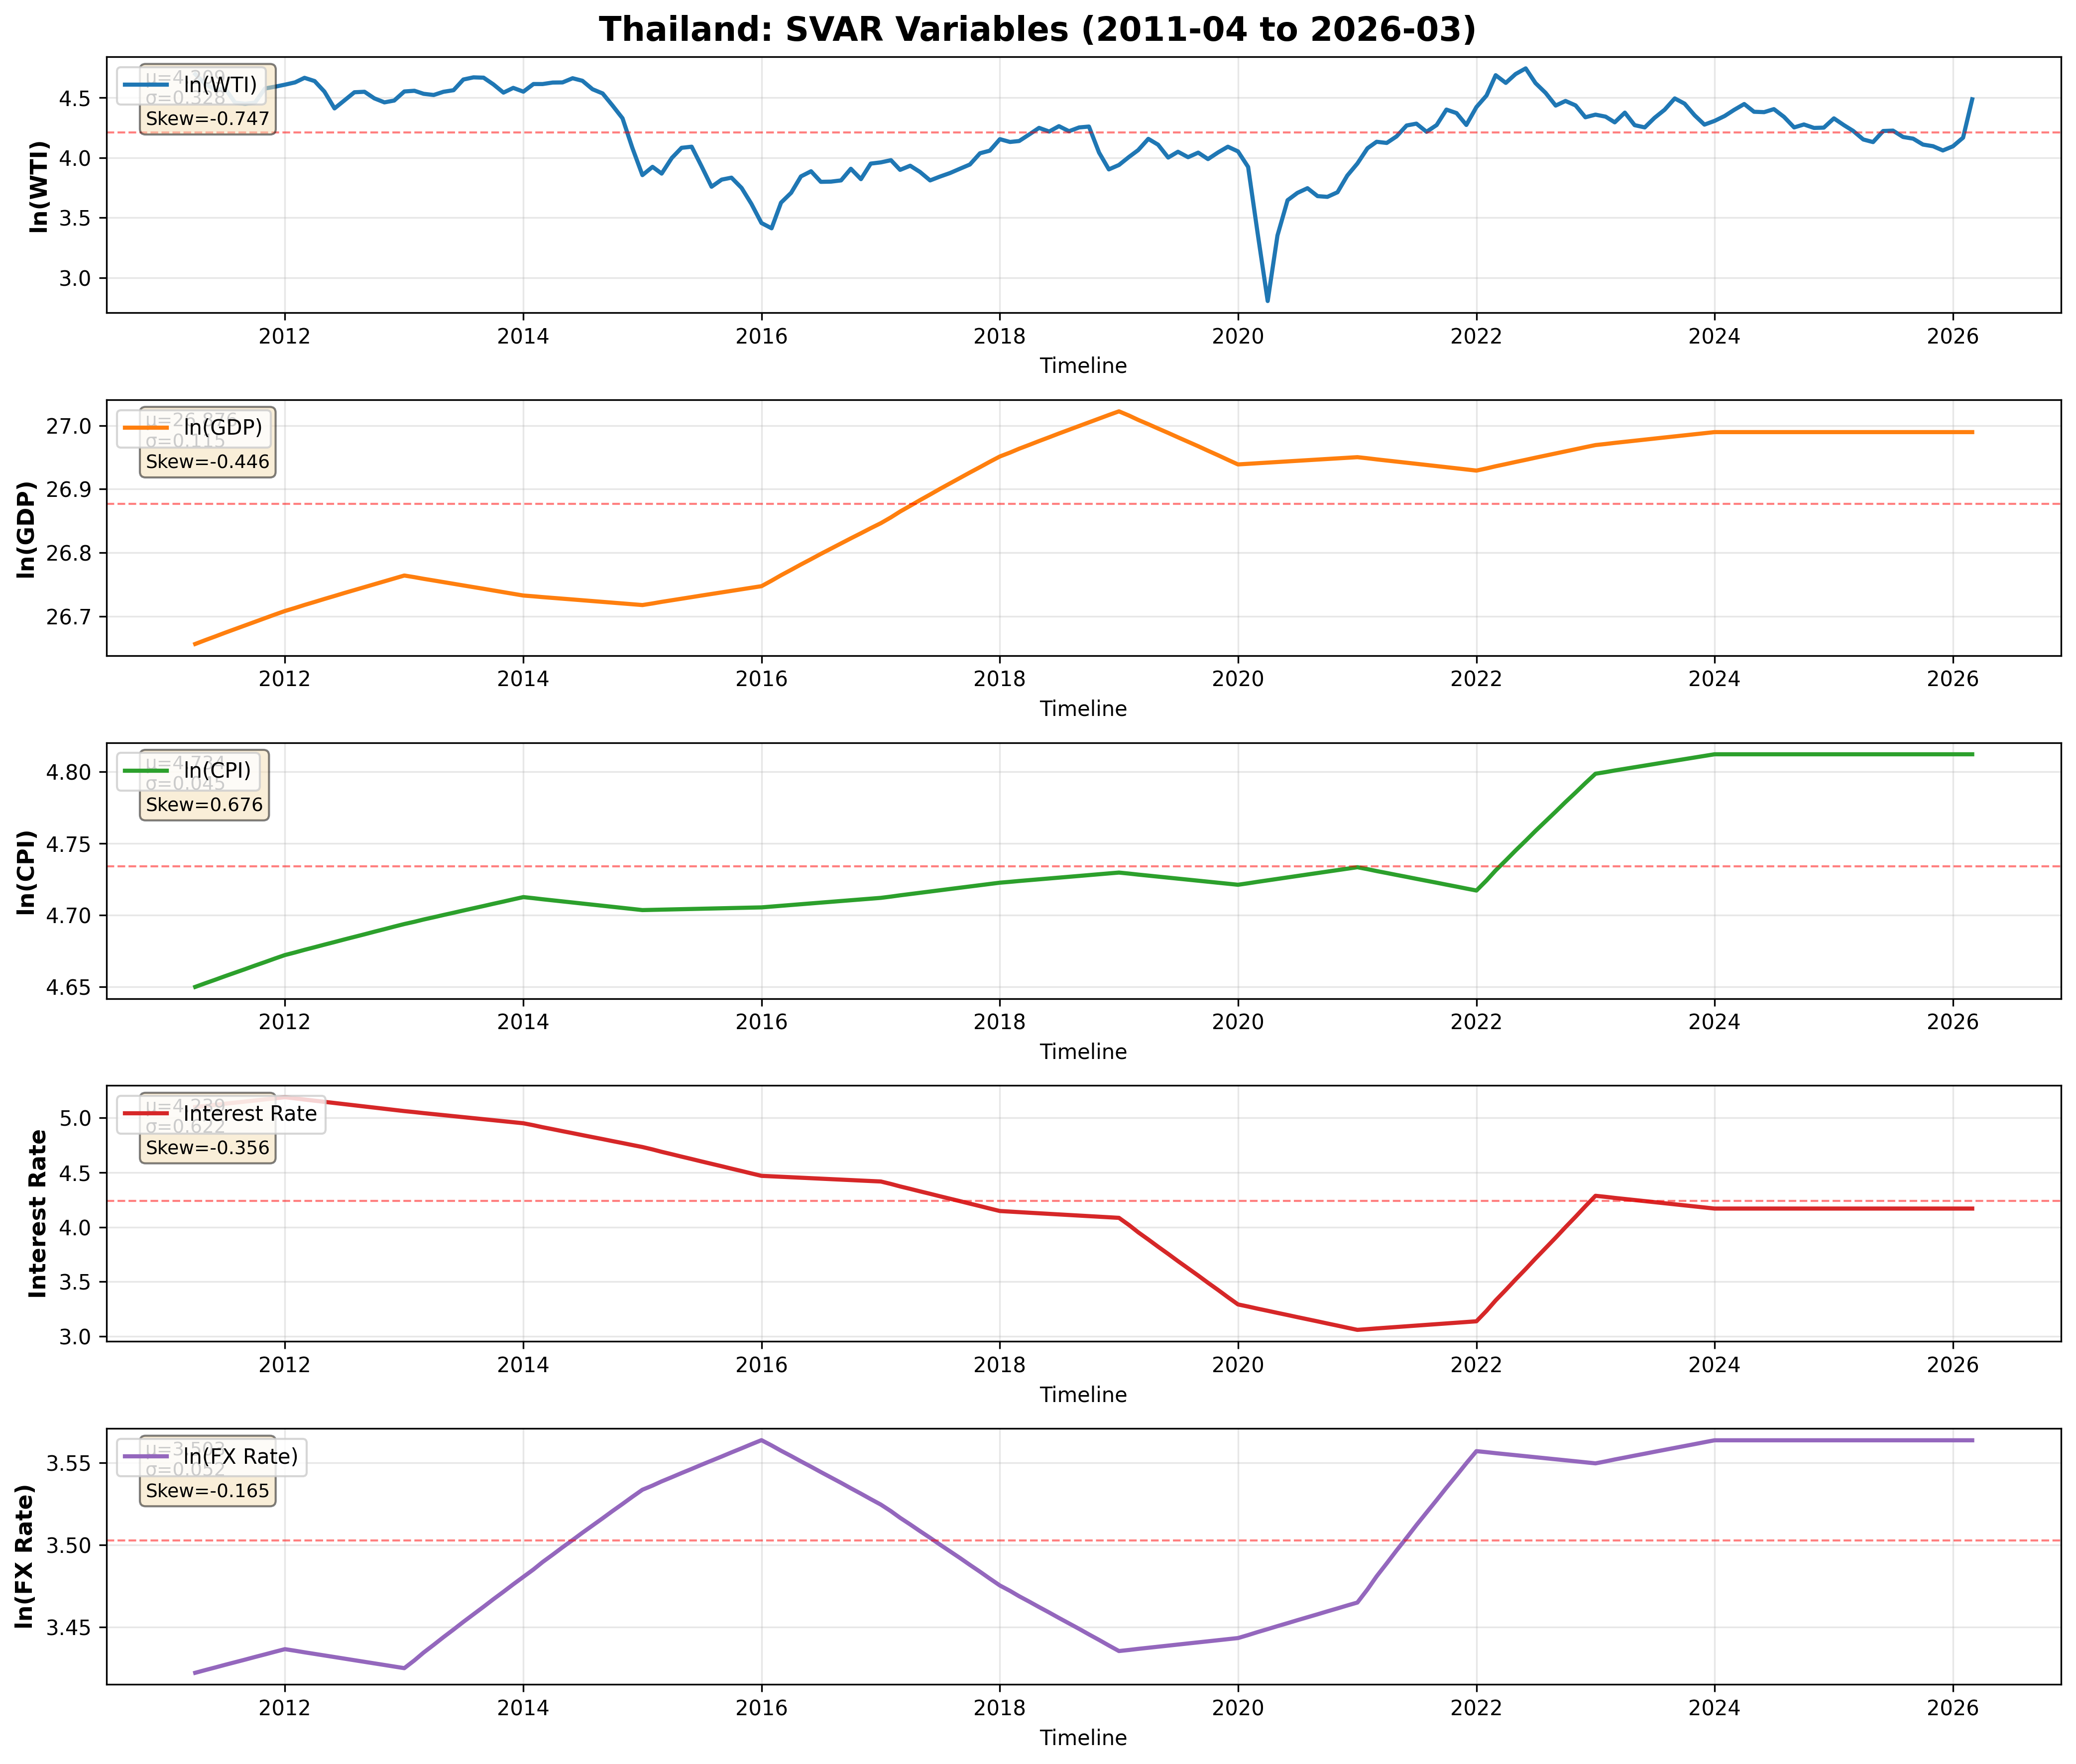


PHASE 1 EDA COMPLETE

Dataset Summary:
  • Period: 2011-04-01 to 2026-03-01
  • Observations: 180
  • Variables: 5
  • Missing values: 0

Next Step: Run /phase2_diagnostics to test for stationarity (ADF/PP tests) and lag selection

✓ Copy your results and paste them back when ready for phase2_decision_doc


In [ ]:
# STEP 5: Time Series Visualizations (5-Panel Subplot)
print("\n" + "="*80)
print("GENERATING TIME SERIES PLOTS")
print("="*80)

fig, axes = plt.subplots(5, 1, figsize=(14, 12))
fig.suptitle('Thailand: SVAR Variables (2011-04 to 2026-03)', fontsize=16, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
variable_labels = ['ln(WTI)', 'ln(GDP)', 'ln(CPI)', 'Interest Rate', 'ln(FX Rate)']

for idx, (col, label, color) in enumerate(zip(df_svar.columns, variable_labels, colors)):
    ax = axes[idx]
    ax.plot(df_svar.index, df_svar[col], linewidth=2, color=color, label=label)

    # Formatting
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Timeline', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=10)

    # Add data range on plot
    mean_val = df_svar[col].mean()
    ax.axhline(y=mean_val, color='red', linestyle='--', alpha=0.5, linewidth=1, label=f'Mean: {mean_val:.3f}')

    # Statistics box
    stats_text = f"u={df_svar[col].mean():.3f}\ns={df_svar[col].std():.3f}\nSkew={df_svar[col].skew():.3f}"
    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(r'..\outputs\timeseries_plots_tha.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ..\\outputs\\timeseries_plots_tha.png")
plt.show()

print("\n" + "="*80)
print("PHASE 1 EDA COMPLETE")
print("="*80)
print(f"\nDataset Summary:")
print(f"  - Period: {df_svar.index.min().strftime('%Y-%m-%d')} to {df_svar.index.max().strftime('%Y-%m-%d')}")
print(f"  - Observations: {len(df_svar)}")
print(f"  - Variables: {len(df_svar.columns)}")
print(f"  - Missing values: {df_svar.isnull().sum().sum()}")
print(f"\nNext Step: Run /phase2_diagnostics to test for stationarity (ADF/PP tests) and lag selection")
print(f"\n✓ Copy your results and paste them back when ready for phase2_decision_doc")